# Preprocessing

## 1. Imports and Setup

In [1]:
import pandas as pd
import numpy as np
import os
import glob
import matplotlib.pyplot as plt
import seaborn as sns

# Define folder path
data_folder = "data/"

# Define tract prefixes
treatment_prefixes = ["48113"]
control_prefixes = ["48201"]

# Define years
years = list(range(2014, 2023))

# Columns to keep
columns_to_keep = [
    "program_label",
    "program",
    "entities",
    "code",
    "number_reported",
    "rent_per_month",
    "hh_income",
    "tpoverty",
]

# Numeric columns
numeric_cols = ["number_reported", "rent_per_month", "hh_income", "tpoverty"]

# Missing / suppression codes
missing_codes = ["-1", "-4", "-5", "NA"]

suppression_threshold = 11

## 2. Helper Functions

In [2]:
def filter_tracts(df, treatment_prefixes, control_prefixes, file_name="unknown"):
    """
    Create treatment indicator and restrict dataset to relevant tracts.
    """
    try:
        # Ensure tract codes are strings
        df["code"] = df["code"].astype(str)

        # Create treatment indicator (1 if treatment prefix, 0 otherwise)
        df["treatment"] = (
            df["code"].str.startswith(tuple(treatment_prefixes)).astype(int)
        )

        # Keep only treatment and control tracts
        valid_prefixes = tuple(treatment_prefixes + control_prefixes)
        df = df[df["code"].str.startswith(valid_prefixes)]

        return df

    except Exception as e:
        print(f"error in filter_tracts for file: {file_name}")
        print(e)
        return df


def processing_missing_values(df, file_name="unknown"):
    """
    Clean dataset by handling numeric conversion, suppression, and missing values.
    """
    try:
        # Ensure code is string type for pattern matching
        df["code"] = df["code"].astype(str)

        # Replace all missing tract codes with NaN
        df.loc[df["code"].str.endswith("999999"), "code"] = np.nan

        # Convert outcome variable first
        df["number_reported"] = pd.to_numeric(df["number_reported"], errors="coerce")

        # Apply HUD suppression rule (< threshold treated as missing)
        df.loc[df["number_reported"] < suppression_threshold, "number_reported"] = (
            np.nan
        )

        # Replace known missing codes across dataset with NA
        df = df.replace(missing_codes, np.nan)

        # Convert numeric columns to integers
        for col in numeric_cols:
            if col in df.columns:
                df[col] = pd.to_numeric(df[col], errors="coerce").astype("Int64")

        # Drop rows with any missing values
        df = df.dropna()

        return df

    except Exception as e:
        print(f"error in processing_missing_values for file: {file_name}")
        print(e)
        return df


def add_year(df, year):
    """
    Add a year identifier to the dataset.
    """
    df["year"] = year
    return df


def create_variables(df):
    """
    Create derived analysis variables.
    """
    # Post-treatment indicator (1 if year >= 2018)
    df["post"] = (df["year"] >= 2018).astype(int)

    # Poverty indicator (1 if tract poverty rate >= 30%)
    df["poverty_indicator"] = (df["tpoverty"] >= 30).astype(int)

    return df

## 3. Process Data

In [3]:
df_list = []

for year in years:
    pattern = os.path.join(data_folder, f"TRACT_*_{year}.xlsx")
    files = glob.glob(pattern)

    for file in files:
        try:
            print(f"Processing file: {file}")

            # Load file
            df = pd.read_excel(file, dtype=str)

            # Filter to HCV program
            df = df[df["program"] == "3"]

            # Keep only needed columns
            df = df[[col for col in columns_to_keep if col in df.columns]]

            # Filter tracts and assign treatment
            df = filter_tracts(df, treatment_prefixes, control_prefixes, file)

            # Process missing values
            df = processing_missing_values(df, file)

            # Add year
            df = add_year(df, year)

            # Warn if dataset becomes empty
            if df.empty:
                print(f"Warning: {file} resulted in empty dataframe after filtering")

            df_list.append(df)

        except Exception as e:
            print(f"Error processing file: {file} in main loop")
            print(e)

# Combine all files
panel_df = pd.concat(df_list, ignore_index=True)

# Create derived variables
panel_df = create_variables(panel_df)

Processing file: data\TRACT_MO_WY_2014.xlsx
Processing file: data\TRACT_MO_WY_2015.xlsx
Processing file: data\TRACT_MO_WY_2016.xlsx
Processing file: data\TRACT_MO_WY_2017.xlsx
Processing file: data\TRACT_MO_WY_2018.xlsx
Processing file: data\TRACT_MO_WY_2019.xlsx
Processing file: data\TRACT_MO_WY_2020.xlsx
Processing file: data\TRACT_MO_WY_2021.xlsx
Processing file: data\TRACT_MO_WY_2022.xlsx


In [4]:
panel_df.tail()

,program_label,program,entities,code,number_reported,rent_per_month,hh_income,tpoverty,treatment,year,post,poverty_indicator
5698,Housing Choice Vouchers,3,TX Texas 201 Harris County 48201555402,48201555402,14,344,13831,15,0,2022,1,0
5699,Housing Choice Vouchers,3,TX Texas 201 Harris County 48201555502,48201555502,19,502,19042,2,0,2022,1,0
5700,Housing Choice Vouchers,3,TX Texas 201 Harris County 48201555701,48201555701,18,521,21242,3,0,2022,1,0
5701,Housing Choice Vouchers,3,TX Texas 201 Harris County 48201556000,48201556000,28,381,16253,15,0,2022,1,0
5702,Housing Choice Vouchers,3,TX Texas 201 Harris County 48201980100,48201980100,118,364,15210,46,0,2022,1,1


## 4. Exploratory Data Analysis

In [5]:
# Show dimensions
panel_df.shape

(5703, 12)

In [6]:
# Show general information about the dataframe
panel_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5703 entries, 0 to 5702
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   program_label      5703 non-null   str  
 1   program            5703 non-null   str  
 2   entities           5703 non-null   str  
 3   code               5703 non-null   str  
 4   number_reported    5703 non-null   Int64
 5   rent_per_month     5703 non-null   Int64
 6   hh_income          5703 non-null   Int64
 7   tpoverty           5703 non-null   Int64
 8   treatment          5703 non-null   int64
 9   year               5703 non-null   int64
 10  post               5703 non-null   int64
 11  poverty_indicator  5703 non-null   int64
dtypes: Int64(4), int64(4), str(4)
memory usage: 557.1 KB


In [7]:
# Show summary statistics
panel_df.describe()

,number_reported,rent_per_month,hh_income,tpoverty,treatment,year,post,poverty_indicator
count,5703.0,5703.0,5703.0,5703.0,5703.000000,5703.000000,5703.000000,5703.000000
mean,69.22532,406.294932,14877.115027,22.038752,0.451692,2017.950377,0.547607,0.263546
std,73.954337,114.750762,3774.176319,12.202966,0.497705,2.589098,0.497772,0.440594
min,11.0,82.0,3198.0,0.0,0.000000,2014.000000,0.000000,0.000000
25%,22.0,325.0,12287.0,13.0,0.000000,2016.000000,0.000000,0.000000
50%,43.0,387.0,14298.0,20.0,0.000000,2018.000000,1.000000,0.000000
75%,88.0,475.0,17023.5,30.0,1.000000,2020.000000,1.000000,1.000000
max,681.0,1084.0,39600.0,79.0,1.000000,2022.000000,1.000000,1.000000


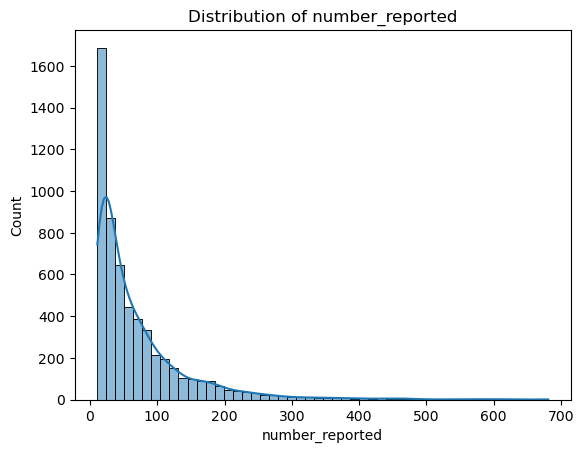

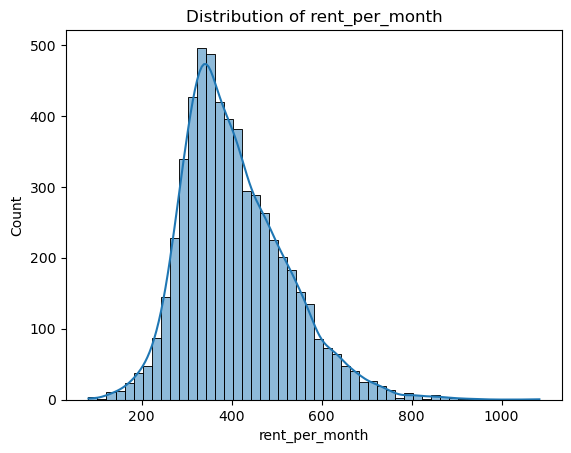

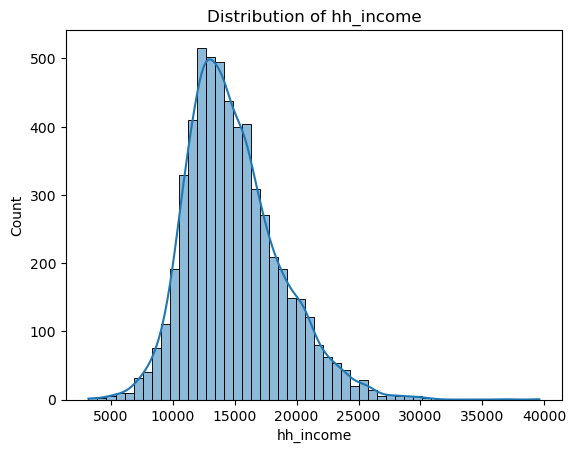

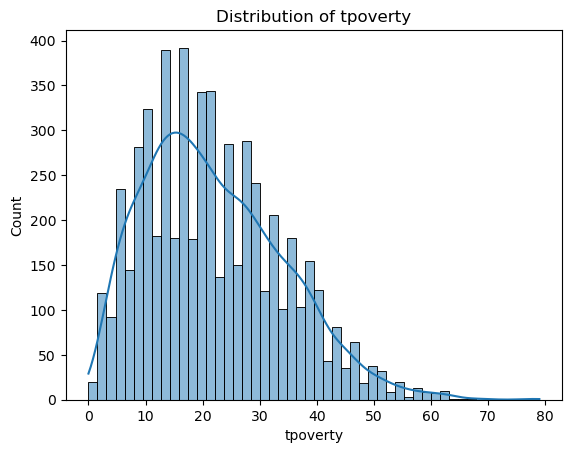

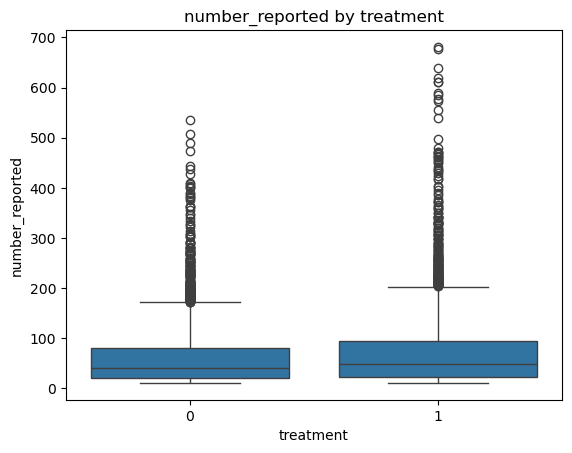

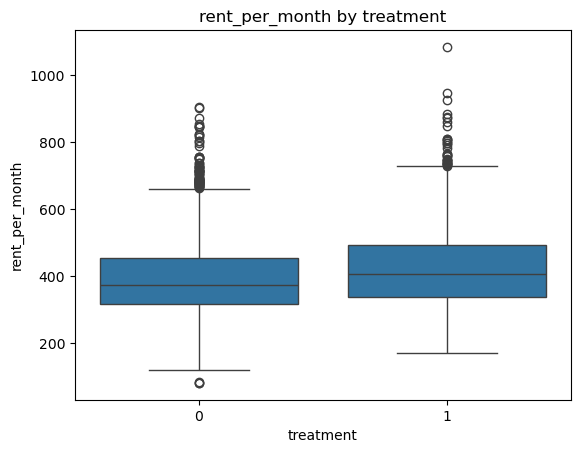

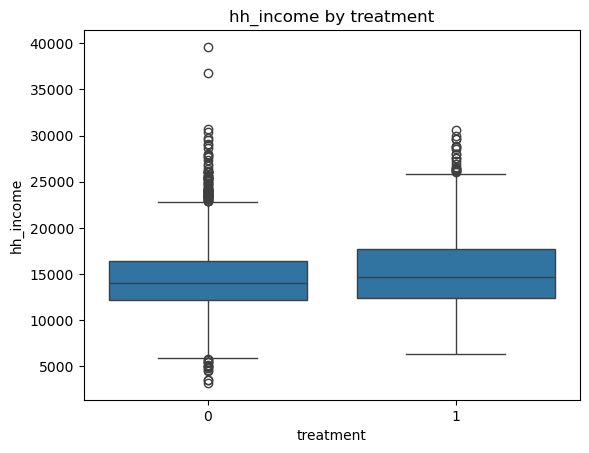

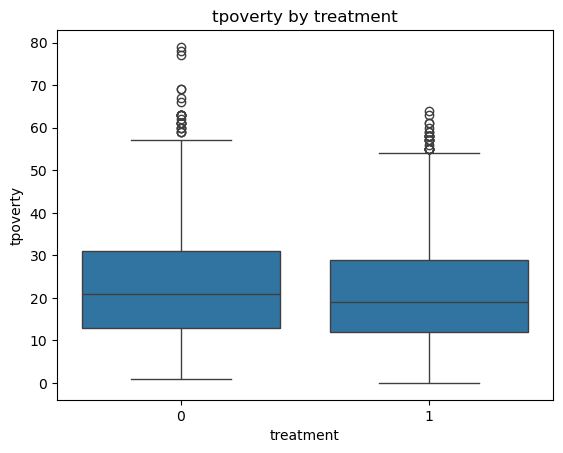

In [8]:
# Plot feature distribution

numeric_cols = ["number_reported", "rent_per_month", "hh_income", "tpoverty"]

# Histogram
for col in numeric_cols:
    plt.figure()
    sns.histplot(panel_df[col], bins=50, kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

# Boxplot
for col in numeric_cols:
    plt.figure()
    sns.boxplot(x="treatment", y=col, data=panel_df)
    plt.title(f"{col} by treatment")
    plt.show()

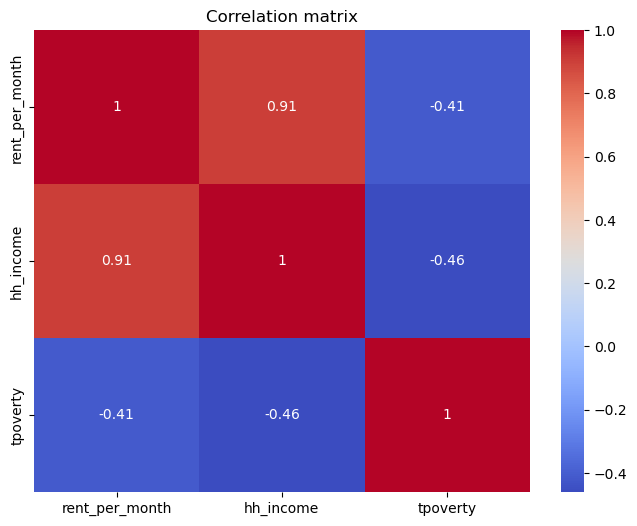

In [10]:
# Feature correlation heatmap
corr_vars = [
    "rent_per_month",
    "hh_income",
    "tpoverty",
]

plt.figure(figsize=(8, 6))
sns.heatmap(panel_df[corr_vars].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation matrix")
plt.show()

## 5. Save Processed Dataset

In [11]:
output_path = os.path.join(data_folder, "clean_hcv_data.csv")
panel_df.to_csv(output_path, index=False)

print(f"Cleaned dataset saved to: {output_path}")

Cleaned dataset saved to: data/clean_hcv_data.csv
